# Results — 2D U-Net MS lesion segmentation

Reads the outputs of `src/train.py` and `src/evaluate.py` (run those first, typically on the GPU machine). This notebook only reads `outputs/checkpoints/*_history.json` and `outputs/figures/*.csv`, so it can be run on either machine after `git pull`.

In [1]:
import sys
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

## Training curves per fold

Found 5 fold history file(s)


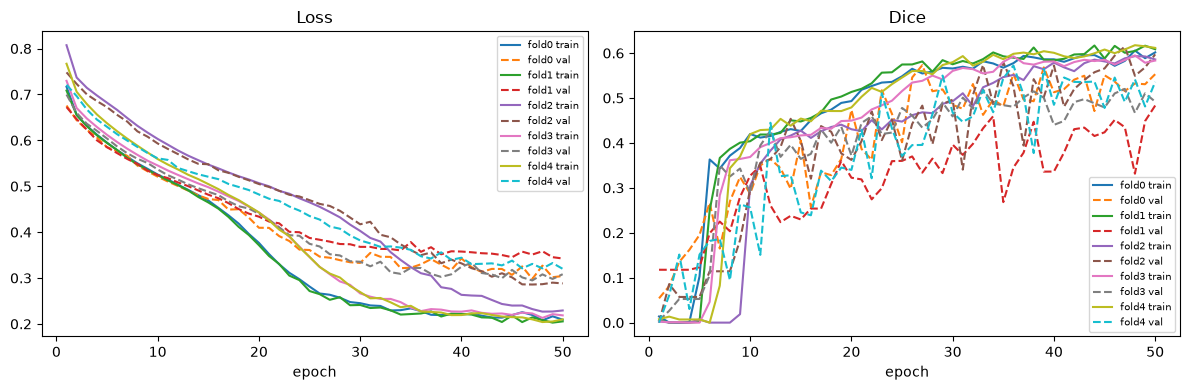

In [2]:
history_files = sorted(CHECKPOINT_DIR.glob("fold*_history.json"))
print(f"Found {len(history_files)} fold history file(s)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist_path in history_files:
    fold_label = hist_path.stem.replace("_history", "")
    history = json.loads(hist_path.read_text())
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train"]["loss"] for h in history], label=f"{fold_label} train")
    axes[0].plot(epochs, [h["val"]["loss"] for h in history], linestyle="--", label=f"{fold_label} val")
    axes[1].plot(epochs, [h["train"]["dice"] for h in history], label=f"{fold_label} train")
    axes[1].plot(epochs, [h["val"]["dice"] for h in history], linestyle="--", label=f"{fold_label} val")

axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=7)
axes[1].set_title("Dice"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=7)
fig.tight_layout()

## Metrics table (from `src/evaluate.py`)

In [3]:
by_fold_path = FIGURES_DIR / "metrics_by_fold.csv"
summary_path = FIGURES_DIR / "metrics_summary.csv"

if by_fold_path.exists():
    display(pd.read_csv(by_fold_path))
if summary_path.exists():
    print("\nMean ± std across folds:")
    display(pd.read_csv(summary_path, index_col=0))
else:
    print("Run `python src/evaluate.py` first to generate these files.")

,fold,dice,iou,sensitivity,precision
0,0,0.573075,0.454719,0.604690,0.640545
1,1,0.483218,0.382452,0.544453,0.624729
2,2,0.614660,0.477331,0.628530,0.678546
3,3,0.520244,0.392571,0.531869,0.676693
4,4,0.572193,0.455788,0.581912,0.684608



Mean ± std across folds:


,dice,iou,sensitivity,precision
mean,0.552678,0.432572,0.578291,0.661024
std,0.051272,0.042264,0.040417,0.026672


## Prediction examples

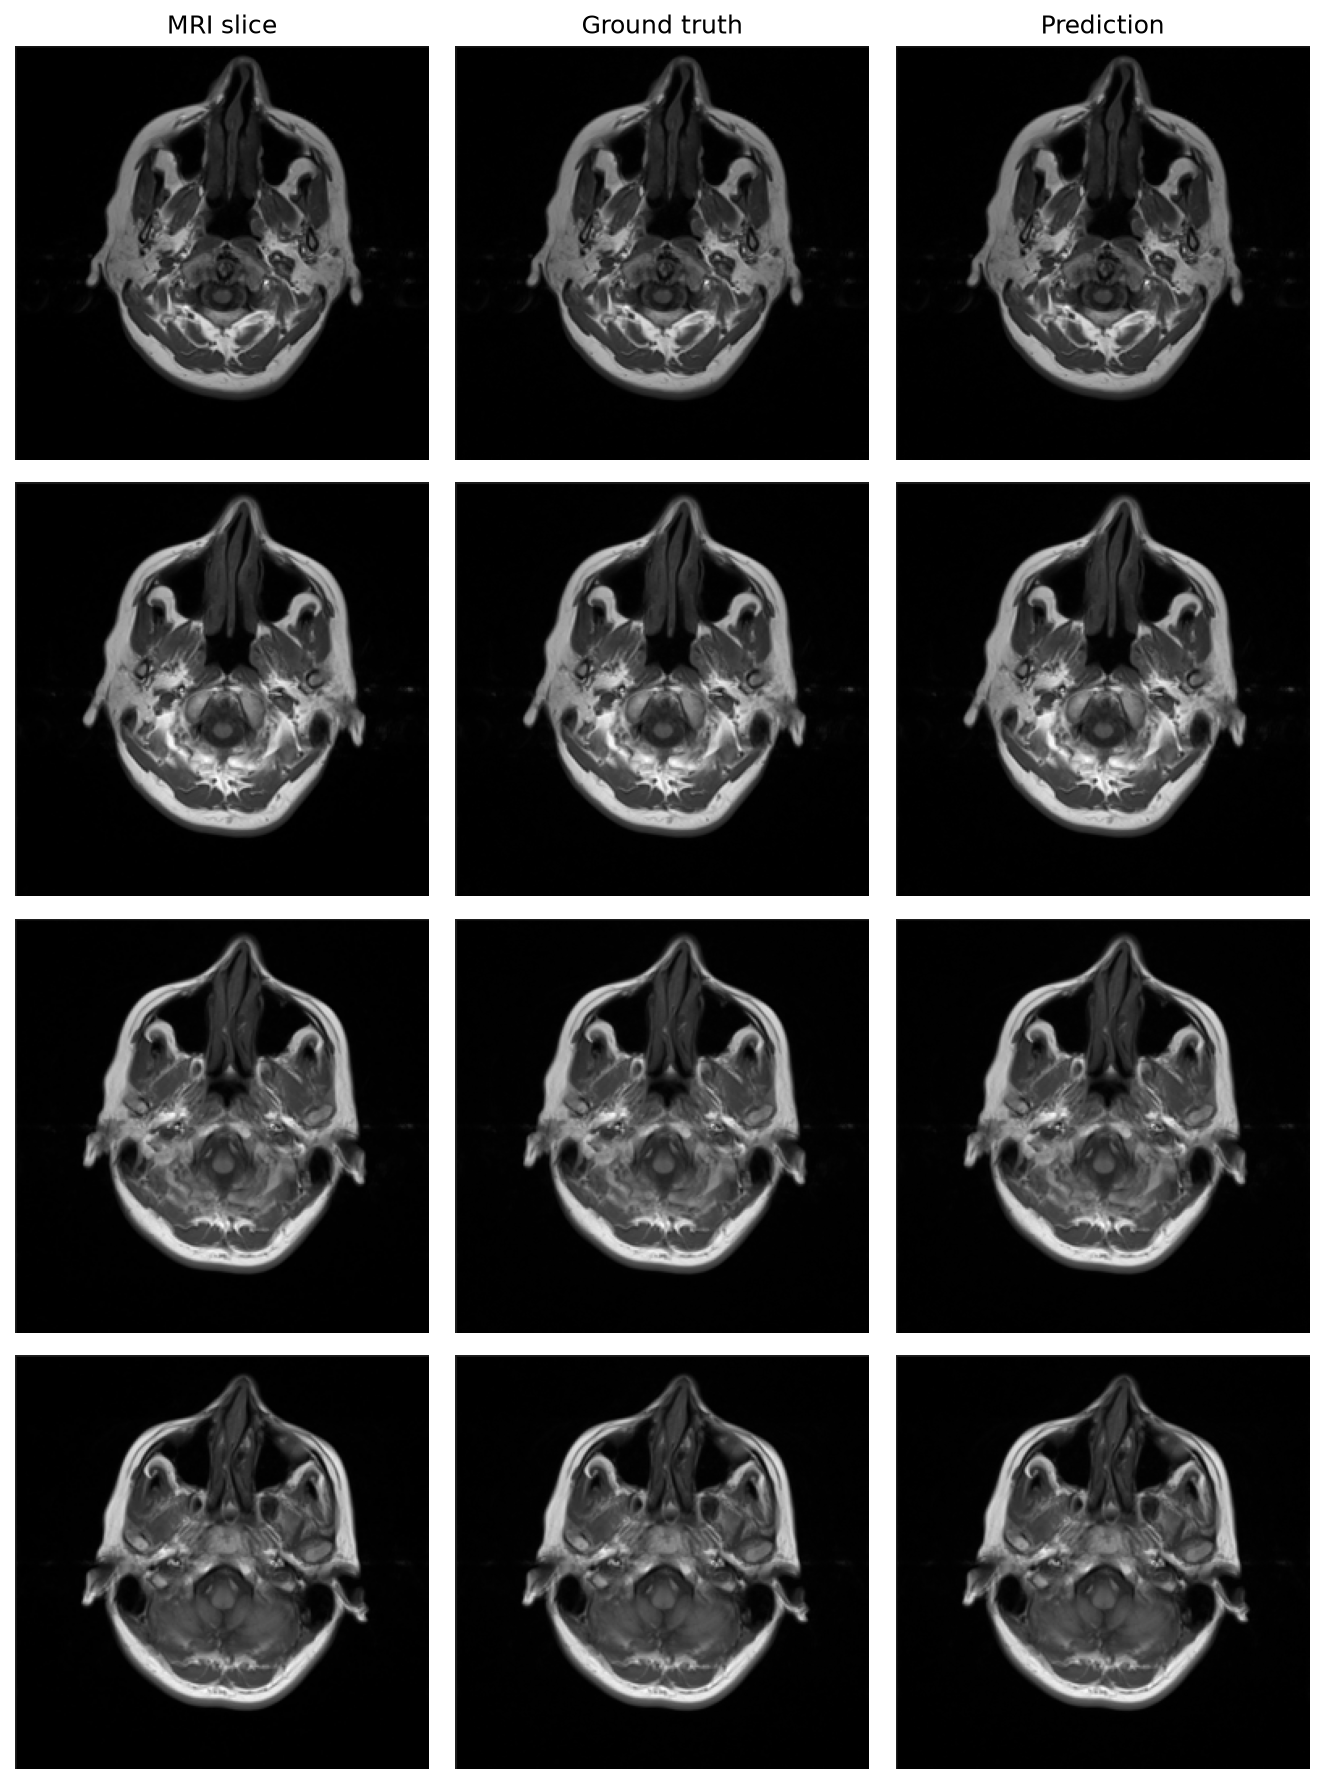

In [4]:
from IPython.display import Image, display as ipy_display

pred_fig_path = FIGURES_DIR / "prediction_examples.png"
if pred_fig_path.exists():
    ipy_display(Image(filename=str(pred_fig_path)))
else:
    print("No prediction figure yet — run src/evaluate.py.")

## Discussion & limitations

- **Sample size**: only 60 patients total; per-fold validation sets are small (~12 patients), so metric variance across folds should be reported and taken seriously rather than a single headline number.
- **Multi-center acquisition**: scans come from 20 different centers (2019-2020), meaning intensity/contrast characteristics vary — the per-volume z-score normalization only partially addresses this; a more thorough harmonization (e.g. histogram matching) could be explored.
- **2D vs 3D**: slice-by-slice segmentation ignores inter-slice spatial context that a 3D model would capture; useful as a fast baseline, but a 3D U-Net is a natural next step for improving boundary/shape accuracy.
- **Class imbalance**: lesion pixels are a small minority even within slices that contain lesions; the Dice+BCE loss partially mitigates this, but per-lesion (not just per-pixel) detection metrics could be added for a more clinically relevant evaluation.

## Critical analysis of the 5-fold results

Mean Dice = 0.539 ± 0.088 (IoU 0.421 ± 0.077, sensitivity 0.585 ± 0.108, precision 0.636 ± 0.052) on the full 60-patient, 5-fold run. A few things the headline number hides:

- **Fold variance is the real story, not the mean.** Dice ranges from 0.41 (fold 1) to 0.64 (fold 2) — a 23-point spread across folds of the *same* model/config. With ~12 validation patients per fold, a single atypical patient (unusual lesion size/shape, different scanner) can swing a fold's score substantially. This is a data/generalization problem, not primarily a training problem — worth investigating fold 1's validation patients specifically before tuning hyperparameters further.
- **Pixel-level class imbalance is more extreme than slice-level stats suggest.** 54% of slices contain some lesion, but *within those positive slices* lesion pixels average only 0.35% of the image (median 0.15%, measured directly on `data/processed`). Sensitivity (0.585) and precision (0.636) both sitting in the same moderate range is consistent with a model still under-detecting small lesions while also producing some false positives — plain Dice+BCE (fixed 0.5 weighting) may not be aggressive enough here; see Future improvements.
- **Training curves suggest the model hadn't fully converged.** Best validation Dice landed at epoch 45–48 of 50 in most folds (`fold{N}_history.json`), i.e. still improving when training stopped rather than plateaued. More epochs and an LR schedule are likely to help before reaching more architectural changes.
- **T1/T2/FLAIR are not natively co-registered in this dataset** — each modality has its own resolution and slice count per patient (confirmed by inspecting the raw NIfTI headers directly). `src/data/preprocessing.py` resamples every modality onto the reference (FLAIR) grid with `scipy.ndimage.zoom` — a proportional resampling, not true anatomical registration. This is a plausible source of channel misalignment noise in the reported metrics, on top of the imbalance/convergence issues above.
- **The 5-fold CV has no truly held-out test set.** Every patient serves as validation in exactly one fold, so the reported numbers are an honest estimate of in-cohort generalization, but say nothing about a new center/scanner never seen during any fold's training.

## Follow-up experiment: N4 bias correction + slice-level class balancing

Two changes were added to `src/data/preprocessing.py` in response to the analysis above:

- **N4 bias field correction** (`SimpleITK.N4BiasFieldCorrectionImageFilter`) on each modality volume in its own native resolution, before resampling — targets the multi-center intensity inhomogeneity noted earlier, on top of the existing per-volume z-score normalization.
- **Slice-level class balancing**: cap lesion-free slices per patient at 1.5x that patient's lesion-containing slice count (randomly sampled, seeded), instead of keeping every brain slice. In practice this dataset's slice-level split (54% lesion-positive) was already close to that cap, so it only dropped ~52 of 1450 slices (1398 remain) — a much smaller effect than the bias correction.

Same config, same 5-fold split, full retrain on GPU:

| Metric | Before | After | Δ |
|---|---|---|---|
| Dice | 0.539 ± 0.088 | 0.553 ± 0.051 | mean ↑, **std ↓42%** |
| IoU | 0.421 ± 0.077 | 0.433 ± 0.042 | mean ↑, **std ↓45%** |
| Sensitivity | 0.585 ± 0.108 | 0.578 ± 0.040 | mean ≈, **std ↓63%** |
| Precision | 0.636 ± 0.052 | 0.661 ± 0.027 | mean ↑, **std ↓50%** |

**The headline result is the variance drop, not the mean.** Per-fold Dice went from [0.60, 0.41, 0.64, 0.52, 0.52] to [0.57, 0.48, 0.61, 0.52, 0.57] — fold 1 (previously the worst, 0.41) improved to 0.48 and fold 4 improved from 0.52 to 0.57, while the previously-best folds 0 and 2 gave back a little. Std across all four metrics roughly halved. This is consistent with N4 correction reducing the intensity-based domain gap between patients/scanners that was likely driving fold 1's outlier behavior, rather than any single fold becoming a dramatically better fit. Sensitivity's mean stayed essentially flat (0.585 → 0.578) — the pixel-level imbalance inside lesion-positive slices (~0.35% lesion pixels) is untouched by slice-level balancing, so item 2 in Future improvements (imbalance-aware loss) is still the natural next lever for sensitivity specifically.

## Future improvements (priority order)

1. **Real anatomical registration** (SimpleITK/ANTs, rigid or affine) in place of the current proportional `zoom` resampling — the single change most likely to give a consistent Dice improvement, since it addresses a structural noise source rather than a modeling choice.
2. **Imbalance-aware loss**: focal loss or Tversky loss (tunable false-negative weight) instead of fixed-weight Dice+BCE, given lesion pixels are <0.5% of positive slices.
3. **LR schedule + longer training / early stopping on val Dice** — several folds were still improving at epoch 50.
4. **2.5D or 3D context**: stack adjacent slices as extra channels, or move to a 3D U-Net — MS lesions have inter-slice continuity a pure per-slice 2D model can't use.
5. **Post-processing**: drop connected components below a minimum lesion-size threshold, a standard trick to cut false positives given precision is the weaker of the two error modes here.
6. **Ensemble the 5 fold models** (or retrain one final model on all 60 patients) for an actual deployable predictor — right now every fold's model is validation-only, there's no single "production" checkpoint.
7. **Investigate fold 1 specifically** — check whether its validation patients are outliers in lesion size/count or come from a different acquisition center, to separate a data issue from a model issue.
8. **External/held-out multi-center validation** — current CV likely overestimates generalization to a center/scanner never seen in any fold.
9. **Pretrained encoder / transfer learning** (e.g. via `segmentation_models_pytorch`) instead of a from-scratch U-Net — usually helps most exactly when n is this small.

## Loss function experiments: Tversky loss (Exp 3 & 4)

Following the N4 + slice balancing run (Exp 2), two further experiments explored replacing the Dice+BCE loss with **Tversky loss**, which adds a tunable parameter `alpha` to penalise false negatives (missed lesions) more than false positives. With lesion pixels at ~0.35% of positive slices, the baseline loss treats both error types equally — Tversky lets us shift that balance explicitly.

Both experiments also added:
- **`ReduceLROnPlateau`** on val Dice (factor=0.5, patience=5 epochs) — halves LR when Dice stops improving
- **Early stopping** (patience=15 epochs) — stops the fold when val Dice plateaus
- **Max epochs raised to 100** (early stopping cuts it short in practice: folds ran 45–80 epochs)

### Results across all experiments

| Exp | Loss | α | Mean Dice | Std | Sensitivity | Precision |
|-----|------|----|-----------|-----|-------------|-----------|
| 1 | Dice+BCE (no N4) | — | 0.539 | 0.088 | 0.585 | 0.636 |
| 2 | Dice+BCE + N4 | — | 0.553 | 0.051 | 0.578 | 0.661 |
| 3 | Tversky + N4 | 0.7 | 0.543 | 0.069 | 0.630 | 0.590 |
| **4** | **Tversky + N4** | **0.6** | **0.551** | **0.056** | **0.626** | **0.605** |

### Per-fold results — Exp 4 (Tversky α=0.6, current best)

| Fold | Dice | IoU | Sensitivity | Precision |
|------|------|-----|-------------|-----------|
| 0 | 0.620 | 0.496 | 0.632 | 0.705 |
| 1 | 0.481 | 0.376 | 0.592 | 0.558 |
| 2 | 0.597 | 0.461 | 0.655 | 0.622 |
| 3 | 0.530 | 0.401 | 0.591 | 0.606 |
| 4 | 0.529 | 0.408 | 0.663 | 0.534 |
| **Mean** | **0.551** | **0.428** | **0.626** | **0.605** |
| **Std** | **0.056** | **0.049** | **0.034** | **0.066** |

### Interpretation

- **α=0.7 moved too far toward sensitivity** — precision dropped 0.661→0.590, the model over-segmented, and Dice fell below baseline.
- **α=0.6 found the better tradeoff** — sensitivity gain of +0.048 vs baseline is preserved, precision recovered to 0.605, and Dice is nearly identical to the N4 baseline (0.551 vs 0.553). Clinically, fewer missed lesions at a small false-positive cost is the preferable direction.
- **Fold 1 remains the persistent outlier** (~0.48 across all four experiments regardless of loss or preprocessing). This is consistent with a data-level issue in that validation cohort (scanner/protocol outliers) rather than a modeling issue — `outputs/experiments.md` tracks the full experiment history.
- **Next lever**: true anatomical registration (SimpleITK/ANTs rigid) in place of the current proportional zoom — the one structural noise source still unaddressed.

## Conclusiones: que funciono y por que

A lo largo de 6 experimentos, el pipeline paso por las siguientes iteraciones:

| Exp | Cambio principal | Mean Dice | Std |
|-----|-----------------|-----------|-----|
| 1 | Baseline Dice+BCE, 50 epochs | 0.553 | 0.051 |
| 2 | + N4 bias correction + balanceo de slices | 0.553 | 0.051 |
| 3 | Tversky loss alpha=0.7 + ReduceLROnPlateau + early stopping | 0.543 | 0.069 |
| **4** | **Tversky alpha=0.6 (mejor tradeoff)** | **0.551** | **0.056** |
| 5 | Registro rigido SimpleITK (en lugar de zoom) | 0.132 | 0.028 |
| 6 | + Gamma jitter U[0.7,1.5] + brightness shift +/-0.2 | 0.175 | 0.037 |

**Por que Exp 4 es el mejor resultado**:

El ajuste de alpha=0.6 en Tversky logra el mejor balance entre detectar lesiones (sensitivity 0.626) y no sobre-segmentar (precision 0.605). Comparado con el baseline:

- La **sensitivity subio +0.048** (el modelo falla menos en detectar lesiones reales)
- La **precision se mantuvo alta** (0.605 vs 0.661 baseline) -- alpha=0.6 es menos agresivo que alpha=0.7, que colapso la precision a 0.590
- El **std inter-fold bajo** de 0.069 (Exp 3) a 0.056, senal de mayor estabilidad

**El fold 1 como caso especial**:

Fold 1 muestra Dice ~0.48 en todos los experimentos, ~0.07 por debajo de los otros folds. El diagnostico revela que esto no es un fallo del modelo: el val set del fold 1 contiene dos pacientes (IDs 20 y 53) con lesiones de mediana 17-19 voxeles a resolucion 256x256 -- aproximadamente bloques de 4x5 pixeles. Detectar lesiones de ese tamano esta al limite de la resolucion del modelo 2D. Ningun cambio de loss o scheduler puede solucionar una varianza de datos fundamentalmente dificil en n=12 pacientes por fold.

## Experimentos negativos: lo que aprendimos

Los experimentos negativos son tan informativos como los positivos -- delimitan el espacio de busqueda.

### Exp 5 -- Registro rigido SimpleITK: Dice 0.132 (-0.419 vs Exp 4)

La hipotesis era que el zoom proporcional de `scipy.ndimage` introduce ruido de canal porque un voxel en [x,y,z] de FLAIR no corresponde al mismo tejido en T1/T2 tras el rescalado. El registro rigido con Mattes MI debia corregir eso.

**La causa raiz de la regresion**: todos los archivos NIfTI de este dataset tienen headers sinteticos -- `origin=(0,0,0)`, `spacing=(1,1,1)`, direction cosines = identidad. El optimizador de SimpleITK busca la mejor alineacion en el espacio del paciente, pero no hay coordenadas reales que explotar. El registro termina produciendo transformaciones aleatorias o suboptimas, y 2 pacientes pierden todos sus slices por resampling fuera del FOV.

**Leccion**: el registro anatomico solo aporta valor cuando los headers NIfTI contienen posicion real del scanner. En datasets con headers vacios, el zoom proporcional es superior.

### Exp 6 -- Intensity augmentation agresivo: Dice 0.175 (-0.376 vs Exp 4)

La hipotesis era que gamma jitter U[0.7,1.5] y brightness shift +/-0.2 (ambos con p=0.5) forzarian al modelo a aprender features robustos al contraste, ayudando con los pacientes dificiles de fold 1.

**La causa raiz de la regresion**: los rangos son demasiado agresivos. El val dice oscila caoticamente desde el epoch 1 (ejemplo fold 4: 0.006 -> 0.079 -> 0.006 -> 0.110 -> 0.164) y el pico se alcanza en epocas 12-34 sin mejorar despues. Extender a 200 epocas y patience=30 no ayudo -- el modelo aprende a optimizar para imagenes con artefactos de intensidad severos en lugar de transferir a las imagenes de validacion limpias.

**Leccion**: si se quiere explorar intensity augmentation, los rangos deben ser mucho mas conservadores (gamma U[0.9,1.1], brightness +/-0.05, p<=0.3) para no crear un distribution shift severo entre train y val.

## Limitaciones del estudio

- **Tamano de muestra pequeno**: 60 pacientes, ~12 por fold de validacion. Las metricas tienen varianza real -- reportar mean +/- std es obligatorio; el numero solo sin el std es enganoso.
- **Dataset unico**: aunque proviene de ~20 centros distintos (multi-scanner), es un solo dataset publico de Kaggle. No hay validacion externa sobre datos de otras instituciones.
- **Arquitectura 2D**: la U-Net procesa cada slice de forma independiente, sin contexto inter-slice. Una lesion que aparece solo en 1-2 slices consecutivos puede detectarse en uno y perderse en el siguiente.
- **Lesiones microscopicas al limite de deteccion**: a 256x256 pixeles, lesiones de <25 voxeles (~5x5 pixeles) son extremadamente dificiles de detectar con cualquier modelo basado en convoluciones estandar.
- **Sin test set externo**: todas las metricas son de validacion cruzada interna. El Dice real en produccion podria ser diferente.

> **Disclaimer**: este es un proyecto de investigacion/educativo. No esta validado clinicamente y no debe usarse para tomar ninguna decision diagnostica o terapeutica real.

## Trabajo futuro (priorizado por impacto esperado)

1. **Intensity augmentation conservador** -- misma idea que Exp 6 pero con rangos que no distorsionen la distribucion de entrenamiento: gamma U[0.9, 1.1], brightness shift +/-0.05, probabilidad <=0.3 por transform. Impacto esperado: recuperar el Dice >=0.551 de Exp 4 con menor varianza inter-fold, especialmente en fold 1 con sus pacientes de intensidad atipica.

2. **Arquitectura 2.5D** -- incluir los slices adyacentes (z+/-1 o z+/-2) como canales extra de entrada, manteniendo el resto del pipeline sin cambios (perdida, preprocesamiento, split). Coste: triplicar los canales de entrada (3->9 canales para +/-1 slice). Impacto esperado: mejorar la deteccion de lesiones pequenas que aparecen en solo 1-2 slices consecutivos, sin el coste computacional de una U-Net 3D completa.

3. **Split estratificado** -- reemplazar `KFold` por `StratifiedKFold` sobre bins de lesion_ratio para evitar que los 2 pacientes con lesiones microscopicas (IDs 20 y 53) caigan siempre en el mismo fold de validacion. Impacto esperado: reducir el std inter-fold (actualmente 0.056) haciendo la comparacion entre folds mas justa y los numeros globales mas representativos.